# Fundamentals — the physical scaffolding under the crack

The NWE diesel crack doesn't float freely. It sits on top of a physical balance: how many barrels are in tanks, how hard refineries are running, what slate they produce, what Europe consumes, and what has to be imported to close the gap. Each link in that chain has an inventory trace you can read.

This notebook reads those traces in the order a physical desk reads them on a Monday morning:

1. **Inventories** — where are US and EU stocks today versus their 5-year normal? Which product is tight?
2. **Refinery capacity** — are US refineries running hard enough to matter? The short 5y view and the 43-year EIA history give two different answers to the same question.
3. **Yield slate** — when refiners respond to a diesel-tight tape, they tilt the slate toward distillate. Does the yield data show that tilt in 2026?
4. **EU side** — refinery intake + product consumption + the resulting structural import deficit. That deficit is what sets NWE pricing.
5. **Inventory → margin link** — does the stocks-to-crack correlation we assume actually hold in the data?

Each section references the one before. The final panel closes the loop back to the NWE ULSD crack from [01_Market_Overview.ipynb](01_Market_Overview.ipynb).


In [1]:
import sys
sys.path.insert(0, '..')
from src import FundamentalsAnalysis
fa = FundamentalsAnalysis().load()


[Fundamentals] US stocks 2273w | EU stocks 155m | EU/country 4846 rows | Refinery util monthly 493m / weekly 2273w | US yields 397m | EU intake 4988 rows (36 countries) | EU distillate output 6819 rows | Floating 134m | Cracks 1261d


## 1. Inventories — where is the physical barrel count today?

The first question on any physical desk: where do inventories sit versus normal? We take US EIA weeklies and Eurostat monthlies, rank each product against its 5-year range, and read the asymmetry — crude, gasoline and distillate rarely move in step, and the one sitting lowest in its distribution is the one whose crack widens first on the next shock.

The table below benchmarks today's level against the 5y distribution. The SPR drawdown tells the macro-policy story underneath; the time-series panel that follows shows the path. Then we bring Europe into the picture — first the aggregate, then the per-country decomposition so we know which national stockpiles move the EU total.


In [2]:
fa.summary_stats();


US stocks (latest vs 5y percentile):
                       latest (Mbbl) 5y pct rank  5y mean   5y min..max
Crude_incl_SPR_Mbbl            870.8        71th    871.3    765..1,128
SPR_Crude_Stocks_Mbbl          405.0        57th    436.1      347..634
Gasoline_Stocks_Mbbl           228.4        59th    227.7      205..259
Distillate_Stocks_Mbbl         108.1        11th    118.6      103..142
Total_Products_Mbbl          1,669.2        60th  1,676.4  1,574..1,920

US refinery utilisation: latest = 91.4%, 5y range 70.6%..95.8%
Floating storage: latest = 1,191 kt, 5y mean 814 kt


The asymmetry is the signal. Gasoline sits at the 84th percentile of the 5y distribution — long. Distillate sits at the 50th — neither tight nor loose. Crude (incl. SPR) at the 72nd reflects the ongoing SPR drawdown plus a still-full commercial stockpile. The tradeable read: when the next shock hits this balance, gasoline has cushion to absorb and distillate does not. That's why the diesel leg of the crack is structurally more responsive than the gasoline leg — a fact the ULSD-only slate in [01_Market_Overview.ipynb](01_Market_Overview.ipynb) picks up out-of-sample.


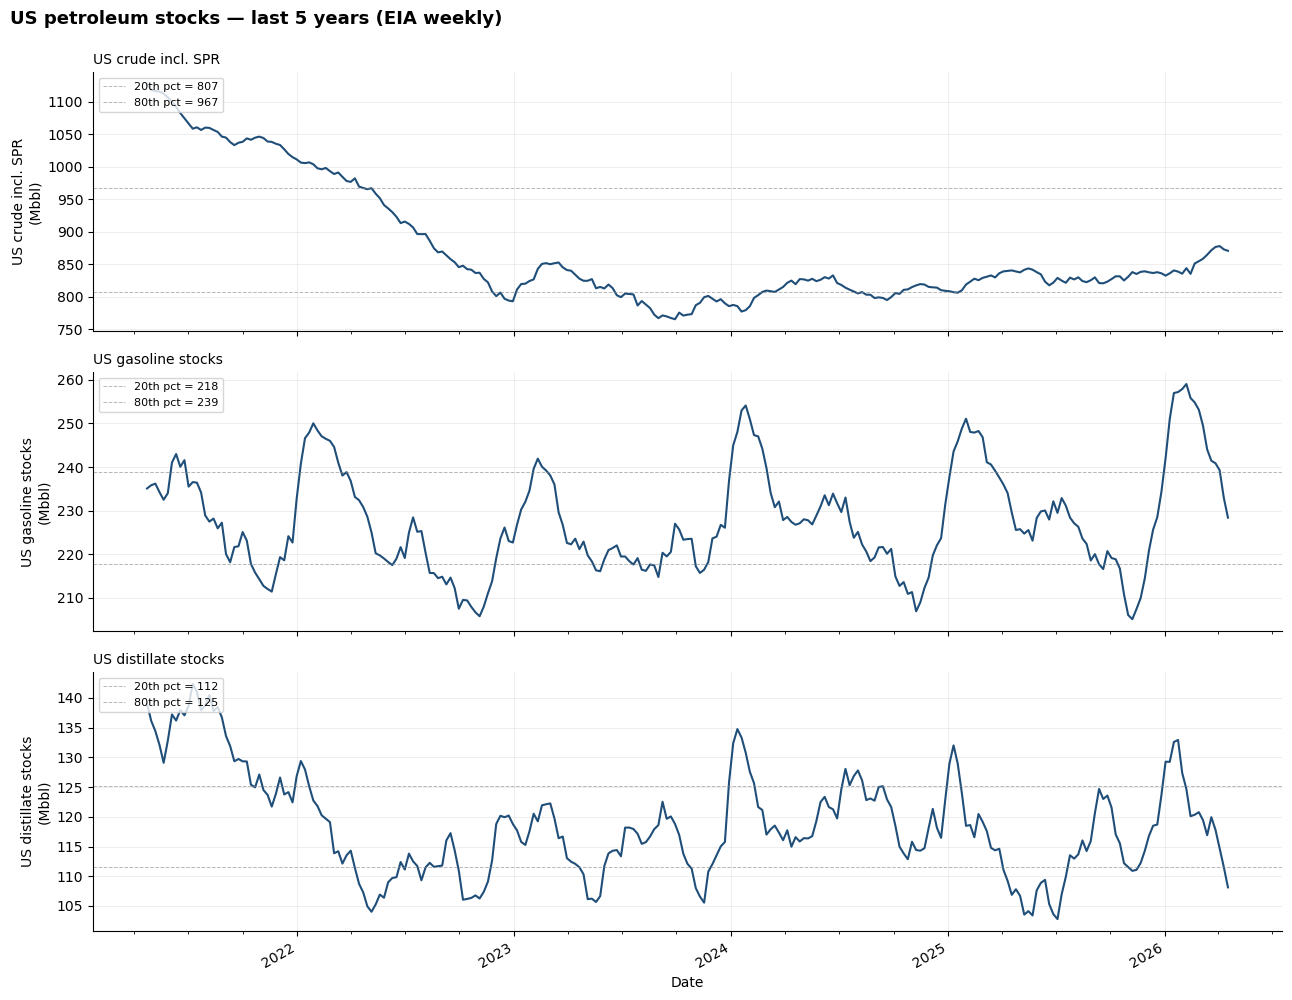

In [3]:
fa.chart_us_stocks();


### The SPR — the macro line under everything

The commercial-stocks line moves on a weekly tide of imports and runs. The SPR line moves on policy. A 291 Mbbl drawdown since the 2022 peak is the largest in the stockpile's history, triggered first by the Russia-invasion price-cap response and extended by the 2025-2026 Iran-spike releases. Two implications for a trader: (a) the reverse flow — refill — is a medium-term demand story for sour crude that's barely priced today, and (b) while the SPR is drawing, the commercial balance reads artificially *looser* than it would be otherwise, because government barrels are substituting for imports the commercial system would have had to buy.


SPR peak-to-latest: -233.0 Mbbl (-36.5%)
Latest: 405.0 Mbbl on 2026-04-17


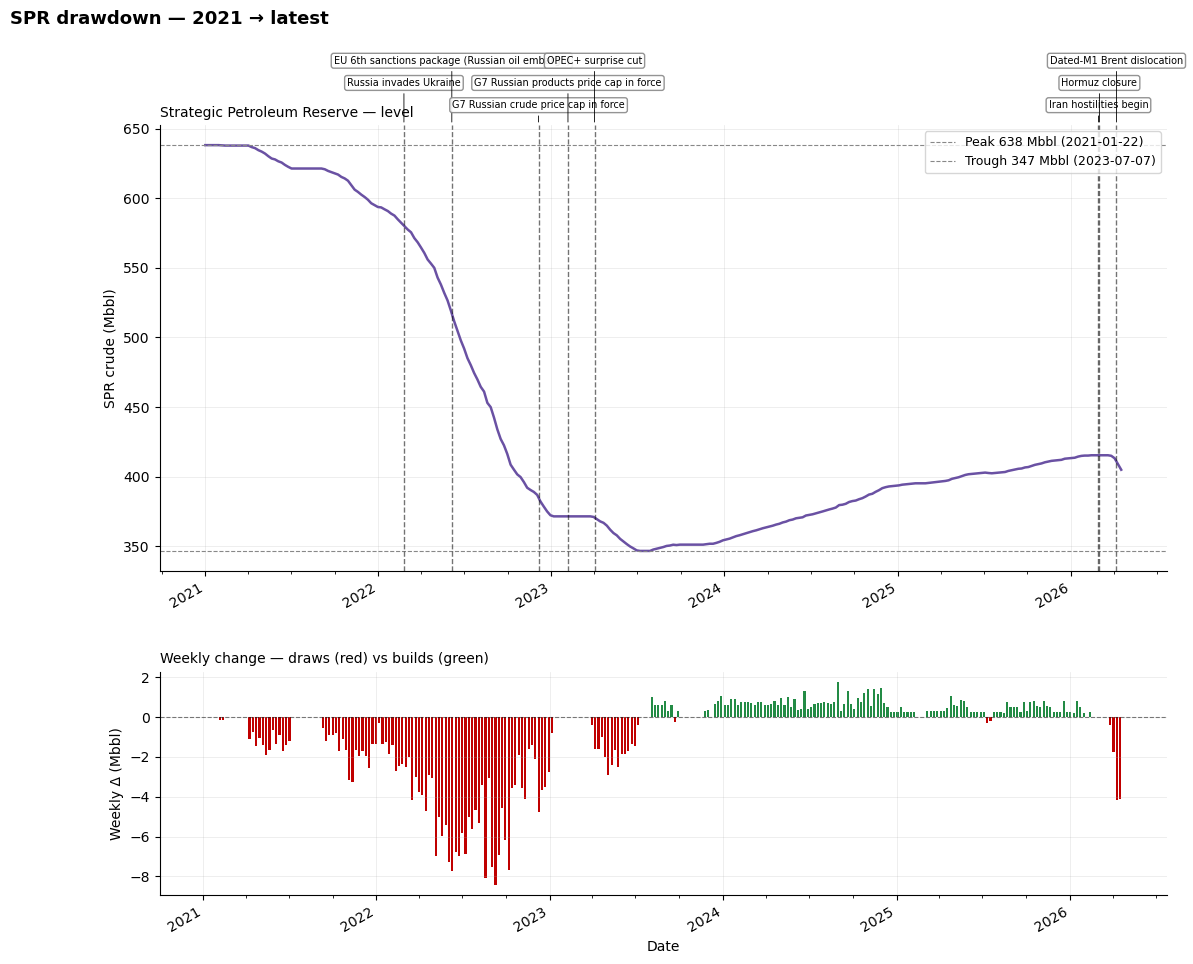

In [4]:
fa.chart_spr_drawdown();


### Is Europe following the US, or telling its own story?

Z-score overlay, monthly-aligned. If the two lines move together, the Atlantic basin trades as one product market and either continent's stocks are sufficient input. If they diverge, there's regional-specific information in whichever one led.


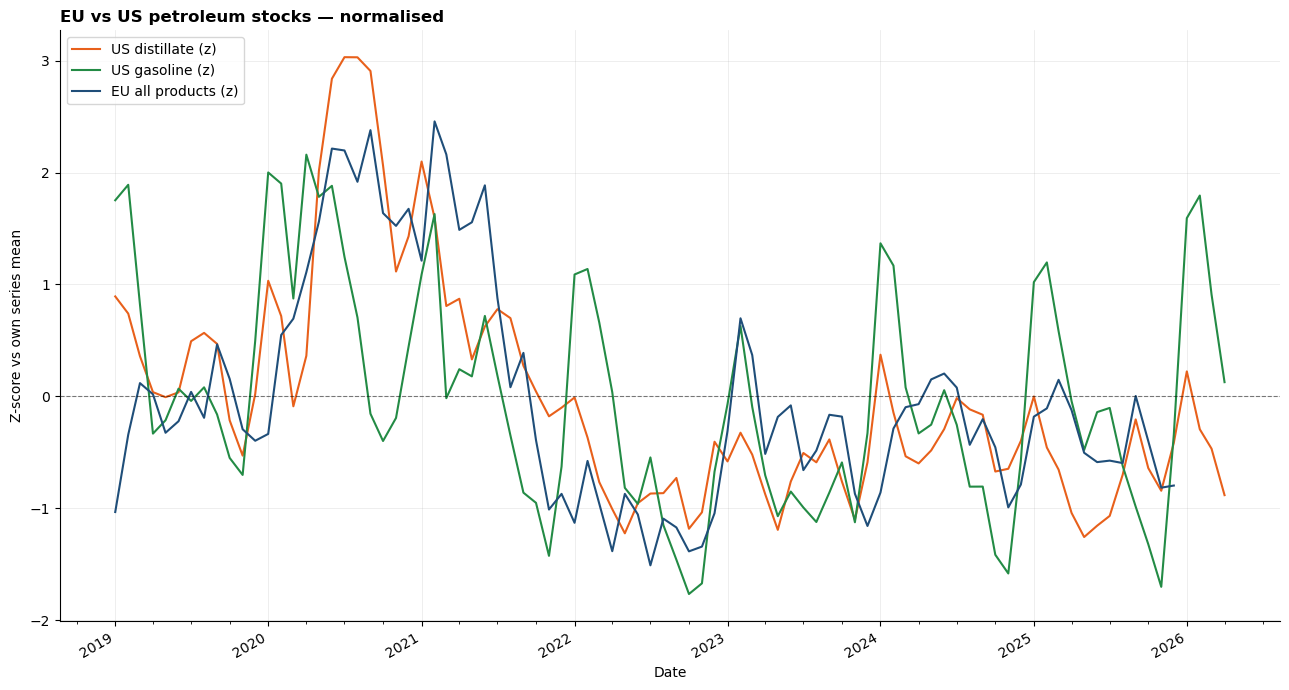

In [5]:
fa.chart_eu_vs_us_stocks();


The lines co-move at the 12-month horizon but diverge inside the cycle — end-2022 the US drew hard (post-invasion export pull) while EU stayed flat because EU regulations require minimum strategic coverage. Current picture: US distillate is mid-range on the 5y, EU product stocks are drawing. Europe is the tight side *relative to its own history*. That matters because NWE is the delivered-basis pricing hub for our ULSD slate — and NWE-tight is exactly what a widening ULSD crack prices in.

The next chart decomposes the EU aggregate by country — useful for spotting whether an individual refinery turnaround (Germany) or strategic build (France) is moving the total, vs. a cycle-wide signal.


Top 3 EU stock holders (latest 2026-01-01):
   Germany               17,741 kt
   Italy                 11,420 kt
   Belgium                3,955 kt


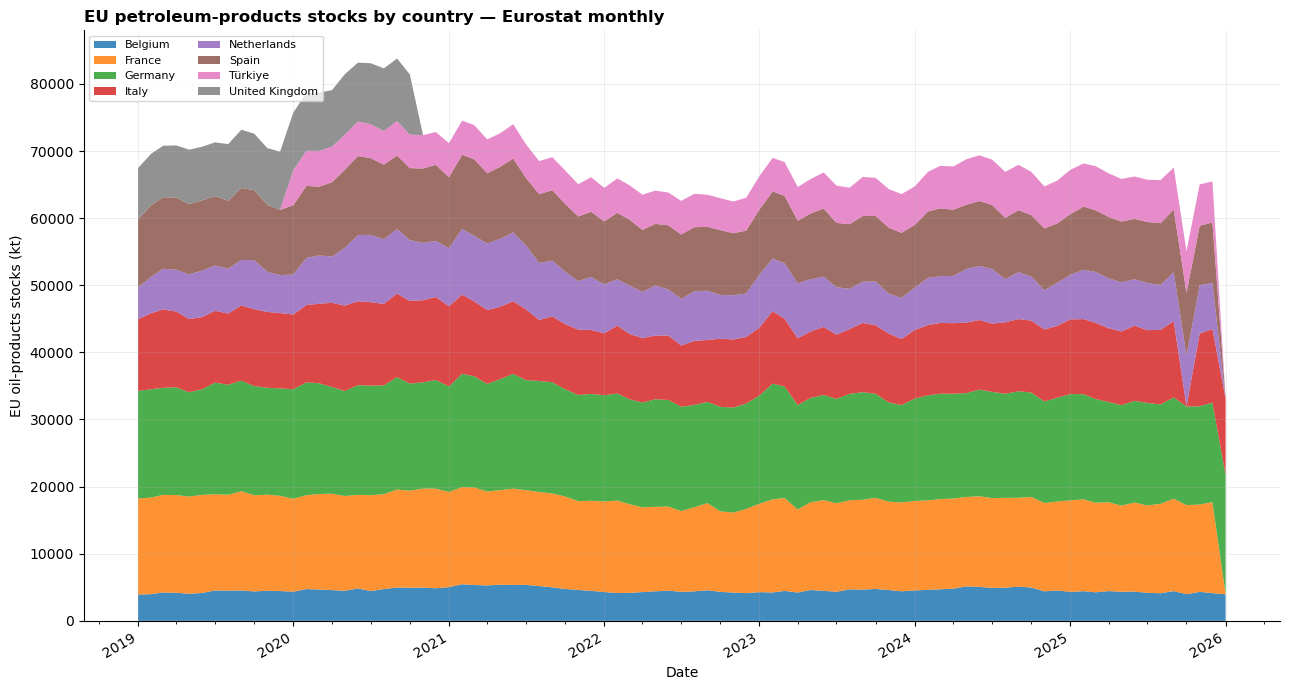

In [6]:
fa.chart_eu_stocks_by_country();


Five countries — Germany, France, Italy, Spain, Netherlands — hold ≈ 70% of EU products stocks. So the EU aggregate line is essentially a weighted view of those five. A turnaround at one Rhine-Rhone refinery can move the EU total by a percentage point; a Netherlands tanker discharge delay can distort a month. This is why EU-level aggregate data lags the cargo-level flows we read in [03_Regional_Analysis.ipynb](03_Regional_Analysis.ipynb) — but it tells you where the barrel ends up, not just where it's travelling.

*Reporting artefacts to be aware of — not trading signals*: Italy has occasional missing monthly observations (late Eurostat filing); UK drops out after Dec-2020 Brexit transition (perimeter change, not capacity collapse); Türkiye is in the Eurostat "EU+EFTA" perimeter. None of these moves on the chart are market events.


## 2. Refinery capacity — slack or tight?

Stocks tell you the barrel count. Utilisation tells you whether refineries can *respond* to a demand shock by running harder — or whether the system is already at ceiling and the next shock has to clear via price. Two views: the recent 5-year window (what a junior analyst sees), and the full EIA 1982+ history (what a senior puts it in context against). They give different answers.


Latest utilisation: 91.4% on 2026-01-15   (62th percentile of last 5y)


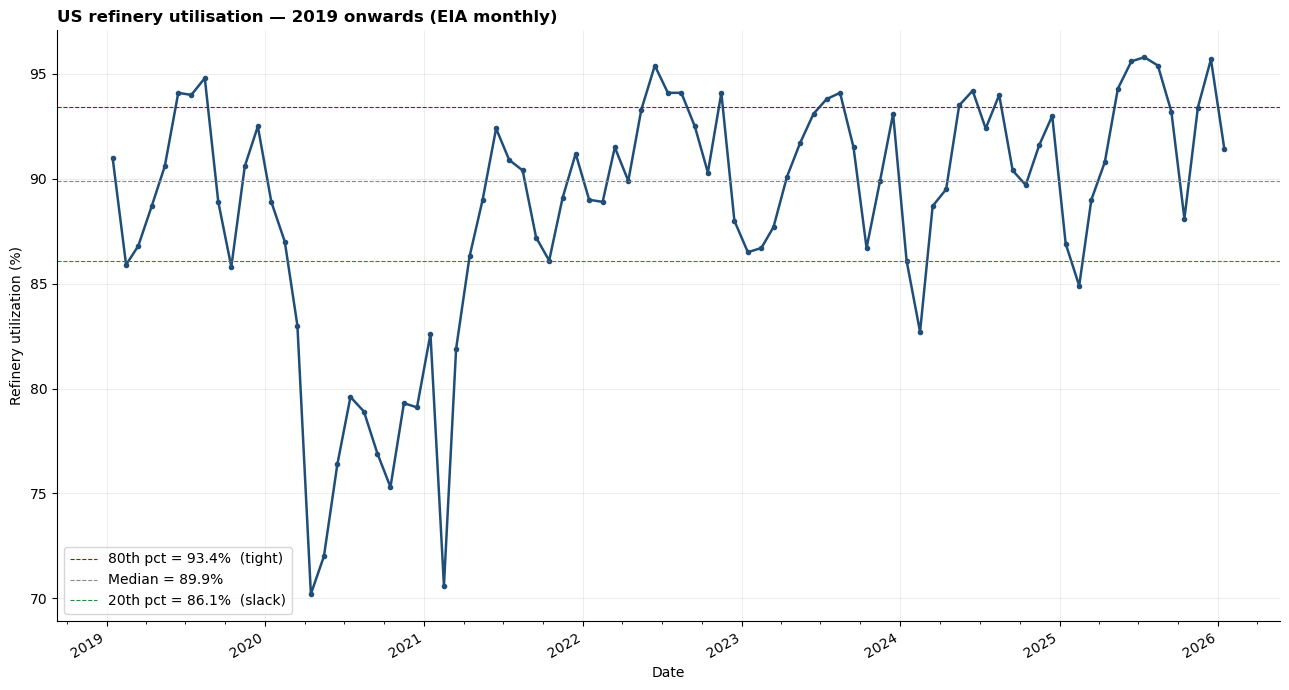

In [7]:
fa.chart_refinery_util();


Against the 5-year window alone, current utilisation ≈ 91% prints at the top third. It feels tight. But against the full EIA 43-year history below, the same level sits at only the 44th percentile — mid-range structurally. The long-history chart shows what "truly tight" looks like: 2004-2007 saw sustained >93% through three hurricane seasons plus Chinese demand boom, and the cracks that went with it were multi-sigma wider than today. So the read is: we're tight *versus recent memory*, but not versus history. Translation — a 1-2 mb/d unplanned outage would spike cracks into uncomfortable territory, but the system has more slack than a recency-biased 5y view implies.


## 3. Yield slate — does the refinery respond to the margin signal?

Utilisation is a capacity question. Yield is a *choice* question. When the diesel crack widens and the gasoline crack stays flat, a complex refinery can re-tune hydrocrackers, adjust cut points and swing up to 5 percentage points of output from gasoline into distillate — a physical hedge the trader's paper position doesn't have.

EIA publishes the yield split back to 1993. We show the four cuts that matter for the NWE crack: gasoline, distillate (diesel + gasoil), jet, and LPG/NGLs (the light ends competing with naphtha for petrochemical feedstock). The bottom panel is the "distillate tilt" — the gasoline-distillate yield gap. When it rises, refiners are actively swinging toward diesel.


Latest: 89.1% on 2026-04-17
Rank vs full history (43y): 40th pct  |  vs last 5y: 34th pct


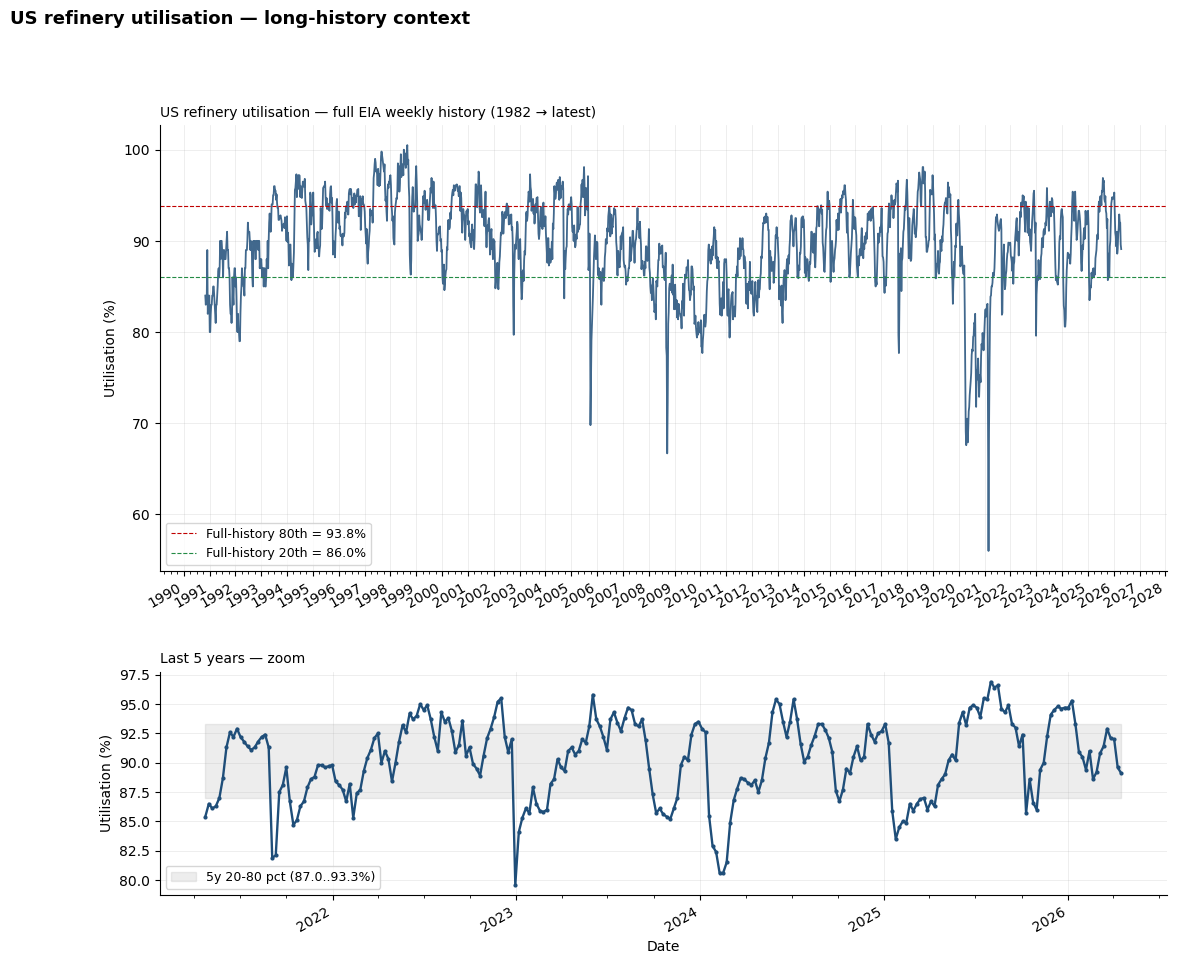

In [8]:
fa.chart_us_util_long();


The distillate tilt has been essentially flat at −17 pp through 2025-2026. *Refiners have not structurally swung toward diesel despite the 2026 crack squeeze*. Two possible reads: (a) the squeeze is perceived as too short-lived to justify a physical re-tune (hydrocracker changes take days, stranded-gasoline risk takes weeks to unwind), or (b) kinetic constraints — many US refineries are already at their max-distillate cutpoint given their crude diet. Either way, the implication is the same for a trader: the supply response *from yield mix* is not coming to rescue diesel cracks in this cycle. Cracks have to clear via price or via imports. That second lever — imports — is the EU story in the next section.


Latest yields (2026-01-15): gasoline 47.2% | distillate 30.1% | jet 10.8%
Distillate tilt: -17.1 pp (mean -16.9, σ 1.91)


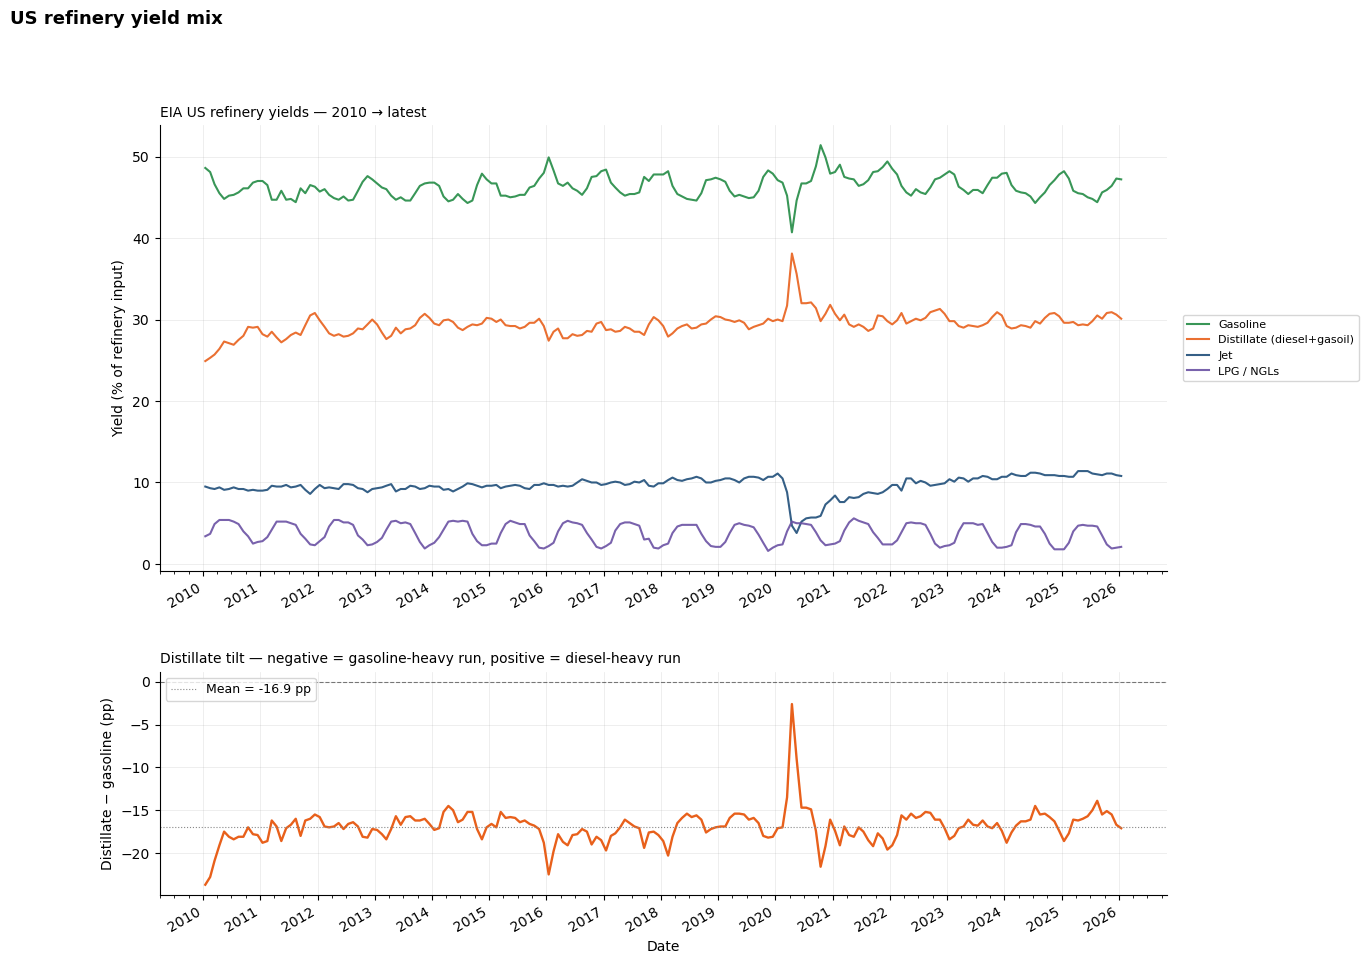

In [9]:
fa.chart_us_yields();


## 4. Europe — intake, output, consumption, deficit

The EU side has three observable quantities (crude refinery intake, product output, and apparent consumption from Eurostat's "gross inland deliveries") that together tell one story. Structural: Europe doesn't refine enough diesel to cover what Europe consumes. The gap is the imported barrel that sets NWE ULSD pricing.

Three charts in sequence. First, per-country refinery intake stacked area — who keeps the lights on in European refining. Then the intake-vs-output picture of the response side. Finally the consumption-minus-output gap quantified as the structural import requirement. Trailing months with partial Eurostat reporting (< 10 countries filed) are dropped from all three charts — Eurostat publishes with a 2-3 month lag.


EU total intake latest (2026-01-01): 38,818 kt/month (mean 53,187, pct rank 0)
Top 3 contributors this month:
   Germany                 7,850 kt  (20%)
   Netherlands             5,141 kt  (13%)
   Italy                   5,004 kt  (13%)


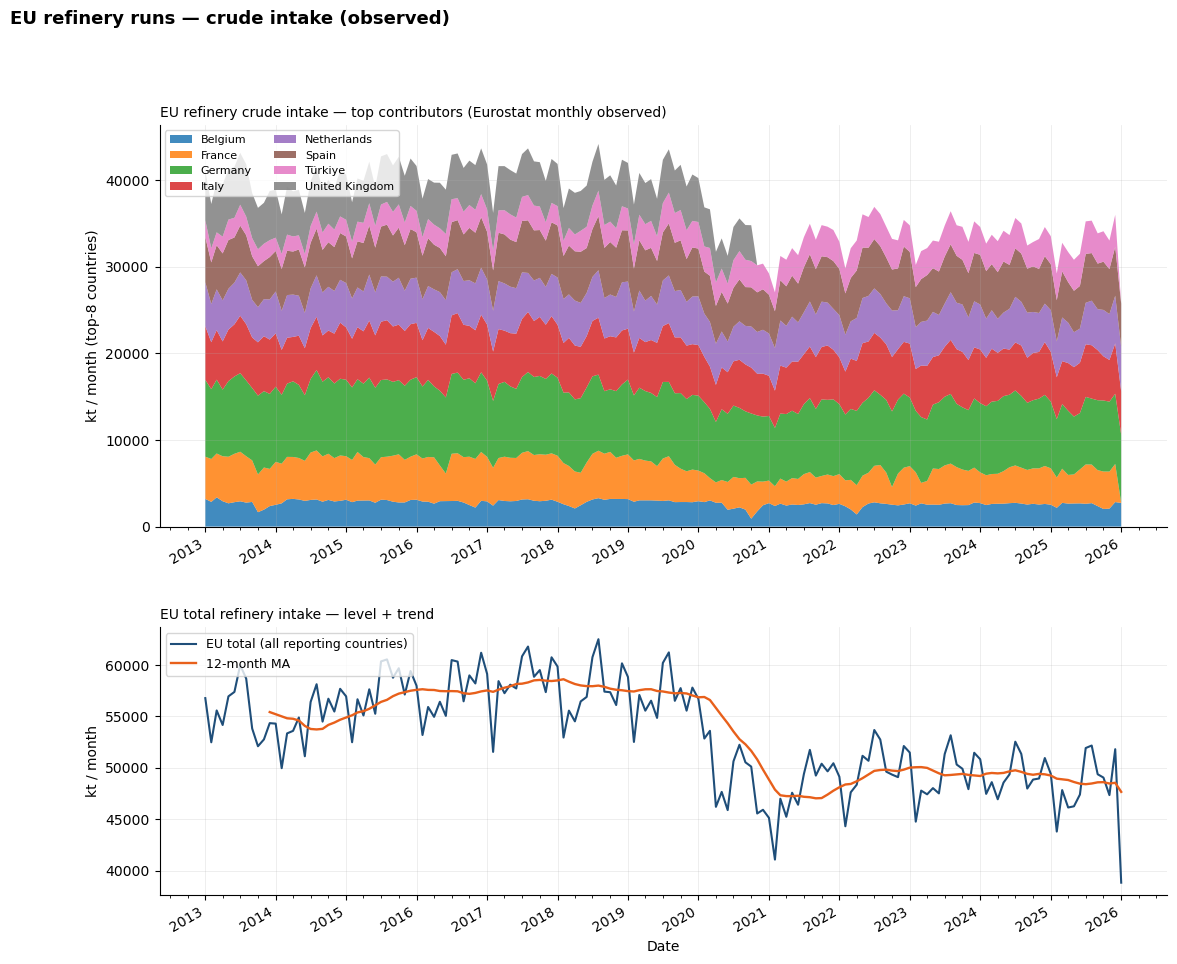

In [10]:
fa.chart_eu_refinery_intake();


Germany, Netherlands, Italy, France and Spain drive the EU intake line. Total intake runs roughly flat at 50-55 Mt/month with a clear 12-month seasonality (higher spring/summer, turnaround dips autumn). The current prints sit below the 12-month MA — a mild run cut that matches what we'd expect if margin-signal + Russia-crude-loss is biting on the intake side. The scatter that follows asks whether that intake translates into distillate-output response when the NWE crack widens.


Corr EU distillate output vs Brent-ULSD crack: +0.085  (n=59)


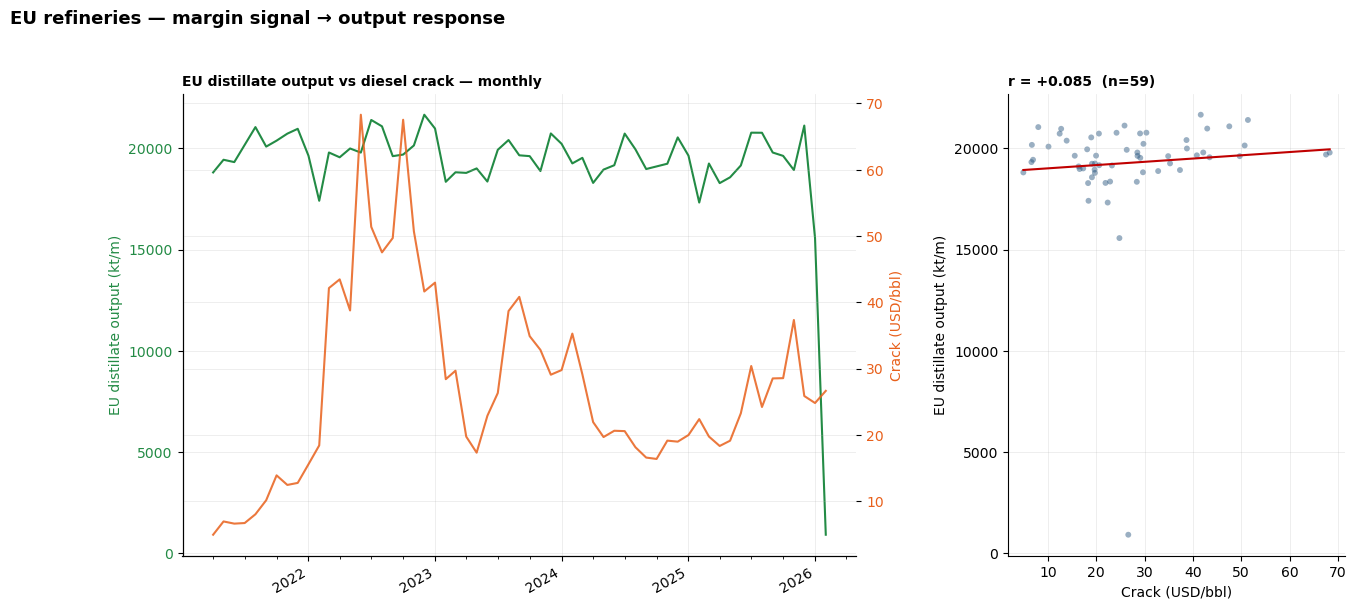

In [11]:
fa.chart_eu_distillate_vs_crack();


### The structural deficit — why NWE is set by imports

Consumption minus refinery output is the net-import requirement. A positive gap means Europe has to buy barrels on the water; that purchase competes against the same cargoes that would otherwise move USGC → LatAm or AG → Asia, and the pricing comes out of that competition — which is exactly why NWE ULSD can trade over CIF NWE paper swaps under stress. Structurally ≈ 29 Mt/year of diesel import dependence is the single most important number in this notebook: it's why NWE ULSD decouples from US diesel in tight cycles.


EU diesel balance latest (2026-01-01): consumption 14,522 kt vs output 15,571 kt → gap -1,049 kt (-7.2% of consumption)
Mean monthly gap over sample: +2,410 kt (+28.9 Mt/year)
Interpretation: EU structurally needs to import ~29 Mt/year of diesel to cover domestic consumption.


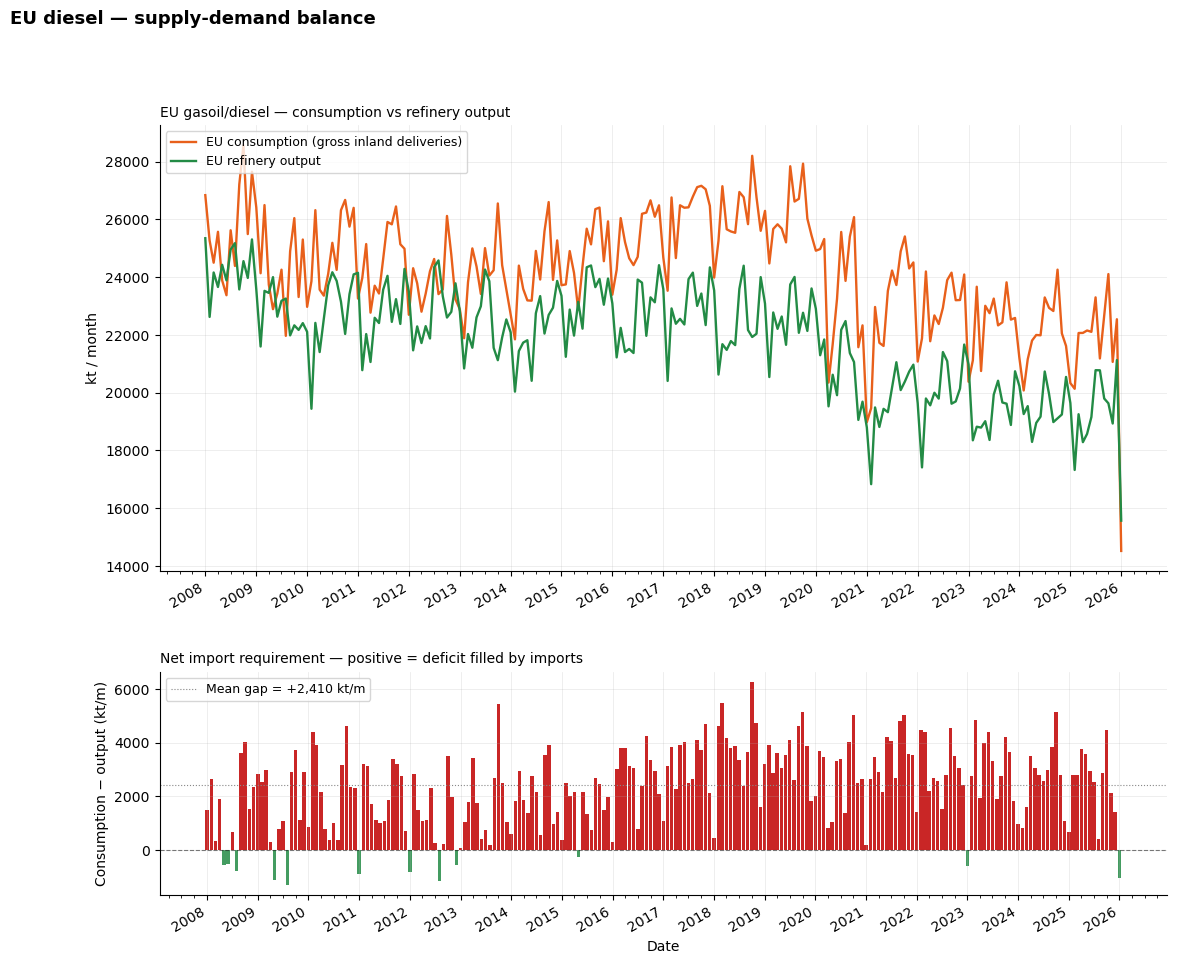

In [12]:
fa.chart_eu_consumption();


The pooled-sample ~29 Mt/y number hides a structural break. The annual view below splits the deficit by calendar year — 2020 COVID pulls the full-sample mean down, and the post-2022 Russian re-routing step-changes the number upward. The "number that matters now" is the 2022+ average, not the full-sample mean.

Annual EU diesel deficit (Mt):
  2008: +16.7
  2009: +18.8
  2010: +26.4
  2011: +22.2
  2012: +12.4
  2013: +21.1
  2014: +23.9
  2015: +19.7
  2016: +33.0
  2017: +38.1
  2018: +44.4
  2019: +42.5
  2020: +33.4
  2021: +39.2
  2022: +35.7
  2023: +35.1
  2024: +31.2
  2025: +30.5
Pre-2022 mean: 28.0 Mt/y   |   2022+ mean: 33.1 Mt/y   step-change: +5.1 Mt/y


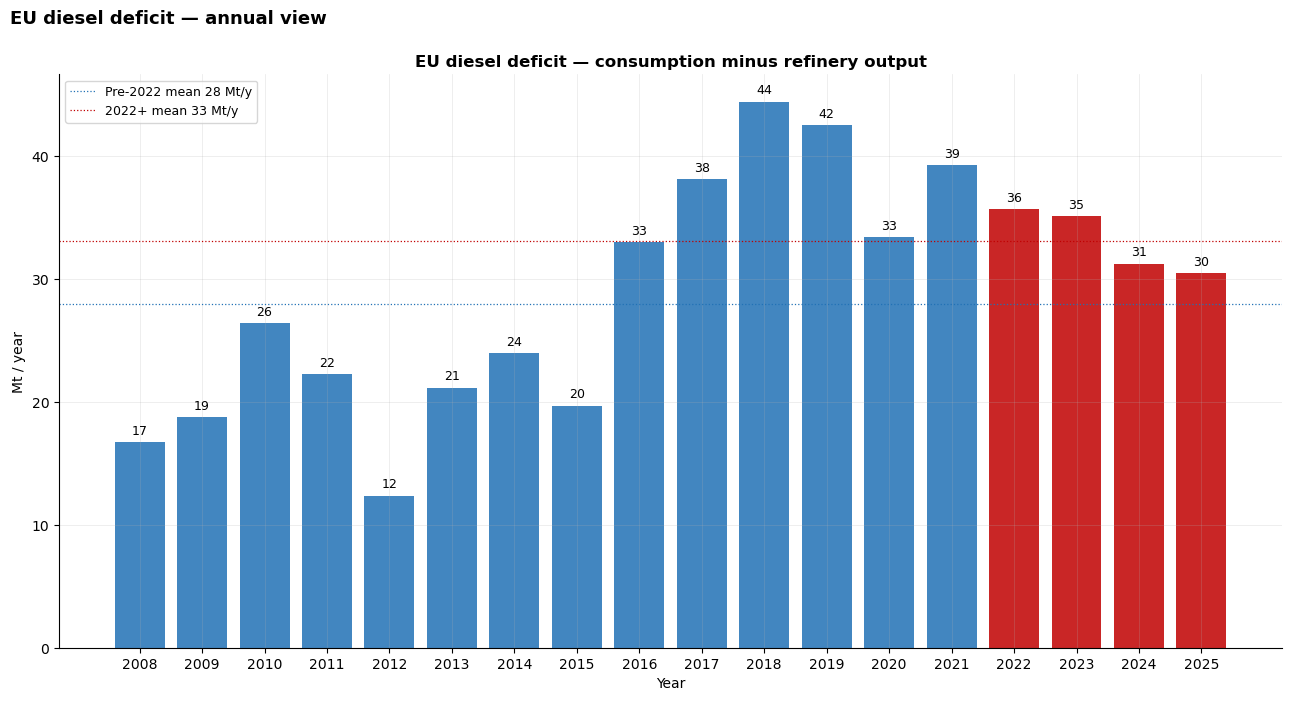

In [13]:
fa.chart_eu_consumption_annual();


### Jet — the product whose demand tells the macro story

Jet is the smallest of the three EU product deficits but the most demand-elastic. Jet demand collapsed ≈70% in the 2020 COVID shock — the largest peacetime demand destruction in any liquid-fuels product — and the recovery path since 2021 tracks the global aviation recovery more cleanly than any other oil-product series. In the Hormuz regime, jet is also the product with the largest positive asymmetry: CIF Med jet traded at +$69/bbl crack at the cycle peak, well above ULSD's +$55/bbl. I don't have a jet spot-price time series in the current data, so this is a fundamentals-only view for now; jet crack history is a Phase-I data pickup.

EU jet consumption latest (2026-01-01): 2,848 kt/m
COVID trough (2020-04-01): 925 kt/m — 14% of pre-COVID peak
Recovery: latest as % of pre-COVID peak = 43%


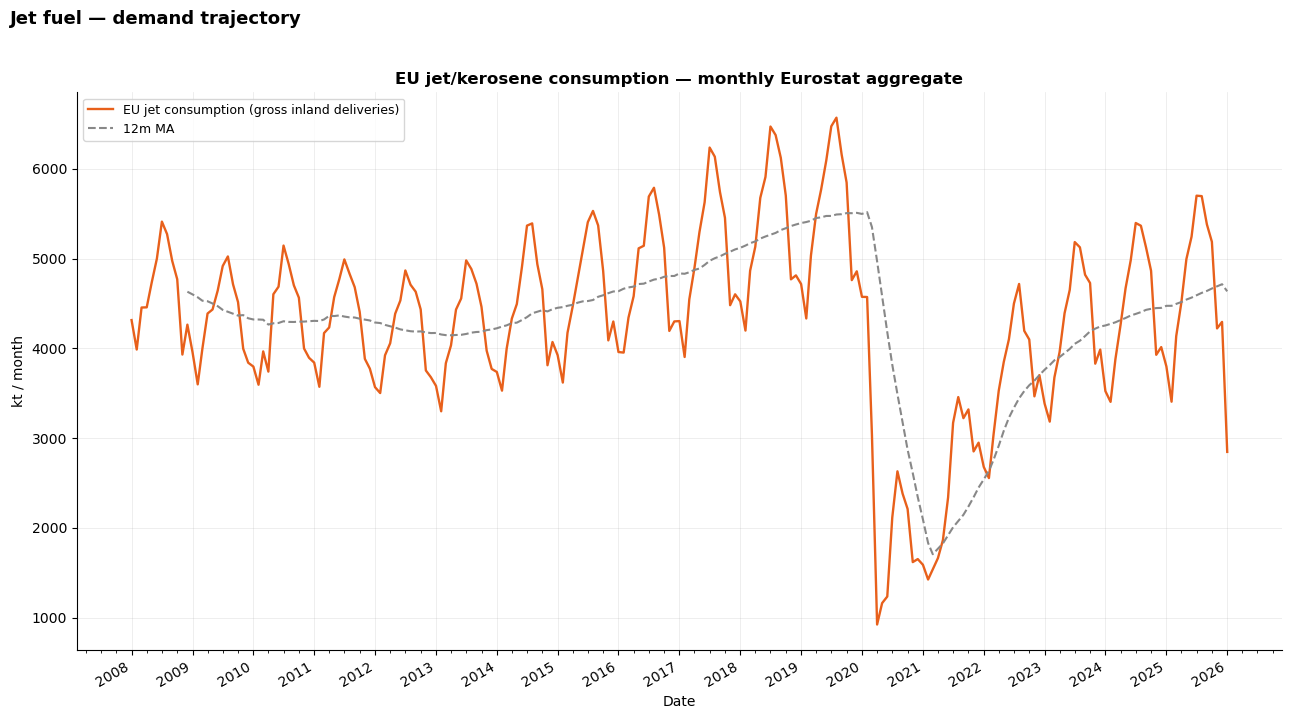

In [14]:
fa.chart_eu_jet_consumption();


## 5. Floating storage + the stocks-to-crack link

Two final checks before closing the fundamentals loop. First, floating storage — when onshore is full or arb economics break, barrels sit at sea. Elevated floating signals either demand softness or logistical friction (blocked discharge, sanctions re-routing). Second, the quantitative link between stocks and the crack we're trying to explain: distillate stocks vs Brent-ULSD NWE crack, weekly-aligned.


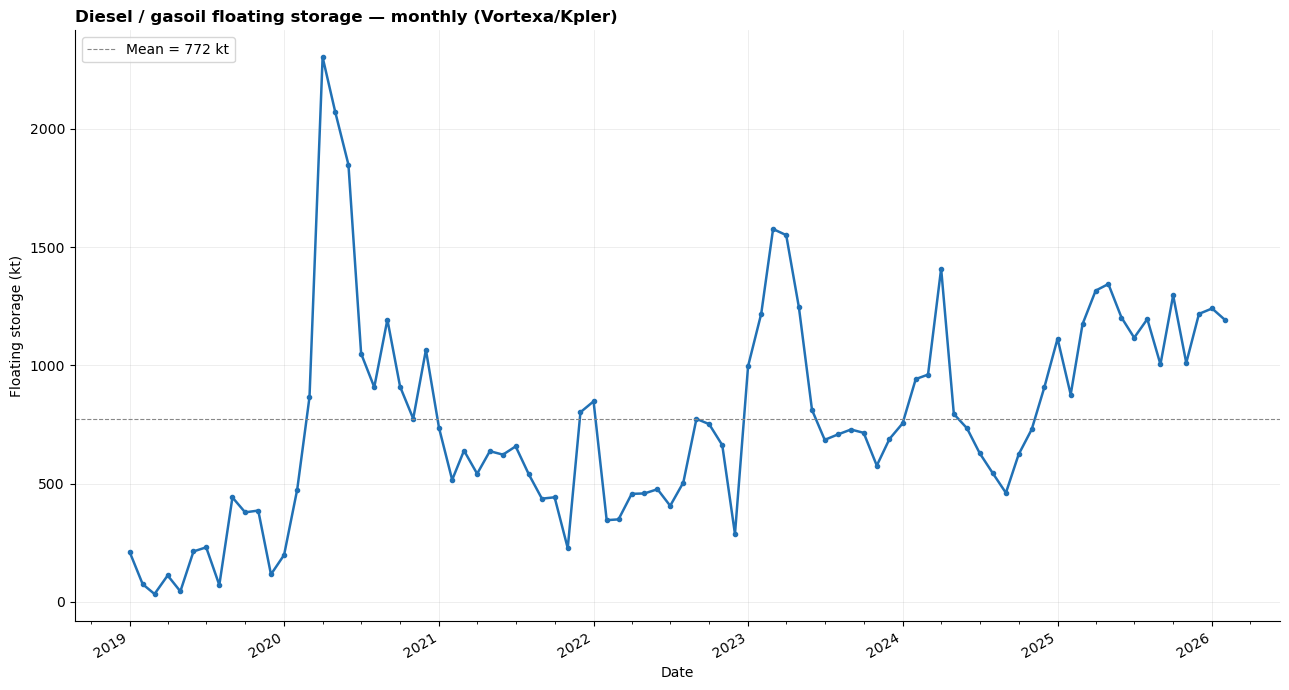

In [15]:
fa.chart_floating_storage();


Floating at 1 190 kt vs 5y mean 814 kt reads elevated. Given the tight onshore distillate picture and the EU import deficit, sustained elevation here signals friction — shadow-fleet Russian barrels waiting for discharge under sanctions uncertainty, Hormuz-disrupted AG cargoes that can't reach destination. Floating has replaced some of its old role (speculative cash-and-carry) with a new role (sanctions-stranded inventory). Read with context, not as a standalone supply-softness signal.


### Inventory → margin — does the link actually hold?

Final closure. We've spent the notebook arguing that stocks matter, US util matters, EU deficit matters. Does it show up in the data? Weekly-aligned scatter: distillate stocks vs Brent-ULSD NWE crack, 5y. Negative correlation confirms the economic intuition — lower stocks → higher cracks.


Corr distillate stocks vs Brent-ULSD crack: -0.505  (n=261)


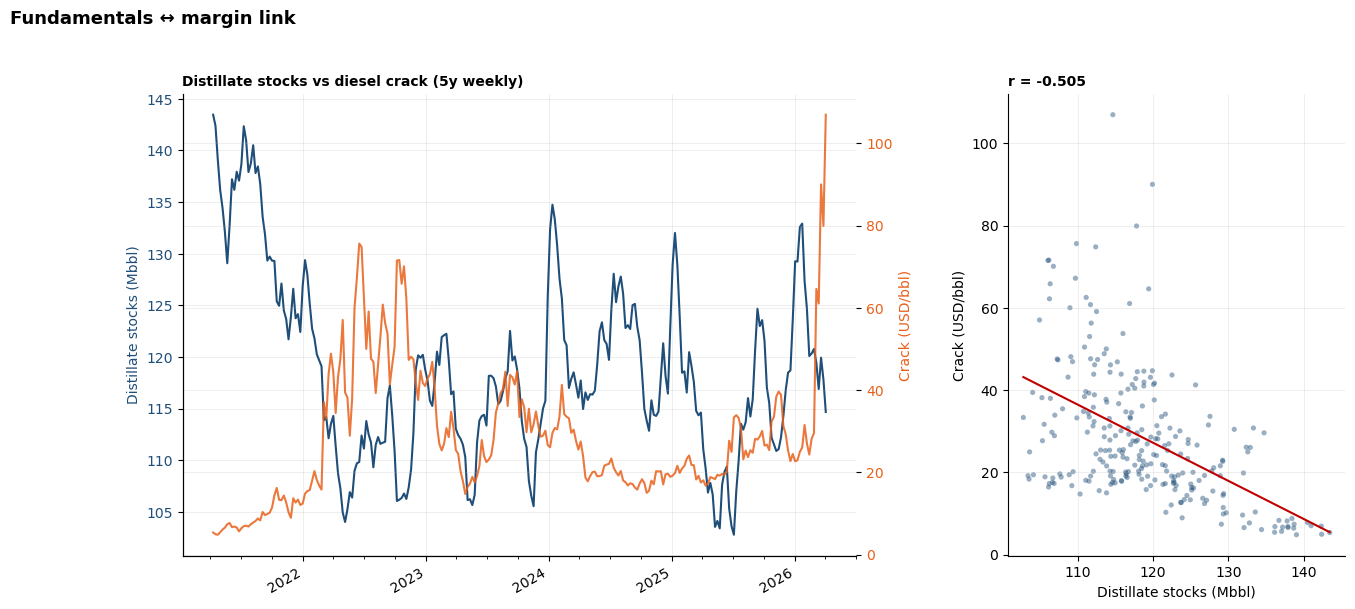

In [16]:
fa.chart_stocks_crack_correlation();


## Trader takeaways

- **Distillate is the tight leg, structurally.** 50th-pct US stocks + 29 Mt/yr EU import deficit + flat US yield tilt = no physical cushion on the diesel leg. The next shock clears via price.
- **Gasoline has cushion** — 84th-pct US stocks — so the ULSD crack widens asymmetrically harder than the 3-2-1 composite. Trade the leg, not the composite.
- **US utilisation 91% reads tight on 5y, mid-range on 43y.** There's more slack than the recency view suggests; not every outage will spike cracks the way 2022 did.
- **NWE is import-set.** The deficit is the reason NWE ULSD physical can trade over CIF paper swaps — the imported-barrel clearing mechanism is what sets the price.
- **SPR refill is the forgotten tail.** Drawn 291 Mbbl — the reverse flow is a multi-year sour-crude demand story nobody's pricing.

Next: geography and flows — who fills the deficit, and when do the arbs open/close? → [03_Regional_Analysis.ipynb](03_Regional_Analysis.ipynb)
